# Lesson 8 - Preventing competitor mentions
# 第八课-避免提及竞争对手

Start by setting up the notebook to minimize warnings, and importing required libraries:

首先设置笔记本以最小化警告，并导入所需的库：

In [37]:
import warnings
warnings.filterwarnings("ignore")
%env TOKENIZERS_PARALLELISM=true

env: TOKENIZERS_PARALLELISM=true


In [38]:
from typing import Optional
# from IPython.display import clear_output

from guardrails import Guard
from guardrails.validator_base import (
    FailResult,
    PassResult,
    ValidationResult,
    Validator,
    register_validator,
)
from guardrails.errors import ValidationError
from transformers import pipeline

import importlib
import helper

importlib.reload(helper)
# Helper functions
from helper import RAGChatWidget, SimpleVectorDB, get_qwen_client

Set up the client, vector database, and system message for the chatbot:

设置聊天机器人的客户端、矢量数据库和系统消息：

In [39]:
# Setup an OpenAI client
unguarded_client = get_qwen_client()

# Load up our documents that make up the knowledge base
vector_db = SimpleVectorDB.from_files("shared_data/")

# Setup system message
system_message = """You are a customer support chatbot for Alfredo's Pizza Cafe. Your responses should be based solely on the provided information.

Here are your instructions:

### Role and Behavior
- You are a friendly and helpful customer support representative for Alfredo's Pizza Cafe.
- Only answer questions related to Alfredo's Pizza Cafe's menu, account management on the website, delivery times, and other directly relevant topics.
- Do not discuss other pizza chains or restaurants.
- Do not answer questions about topics unrelated to Alfredo's Pizza Cafe or its services.

### Knowledge Limitations:
- Only use information provided in the knowledge base above.
- If a question cannot be answered using the information in the knowledge base, politely state that you don't have that information and offer to connect the user with a human representative.
- Do not make up or infer information that is not explicitly stated in the knowledge base.
"""

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initialize the chatbot using the settings above:

使用上面的设置初始化聊天机器人：

In [40]:
rag_chatbot = RAGChatWidget(
    client=unguarded_client,
    system_message=system_message,
    vector_db=vector_db,
)

To revisit the going competitor mention example from Lesson 1, run the cell below to open the chatbot then paste in the prompt to see the unwanted behavior:

要重新访问第1课中的竞争对手提及示例，请运行下面的单元格以打开聊天机器人，然后粘贴提示符以查看不想要的行为：

In [41]:
rag_chatbot.display()

In [ ]:
# Copy and paste this prompt into the chatbot above:
# 我想订一份很大的披萨。作为消费者，我为什么要从阿尔弗雷多的披萨咖啡馆买披萨而不是阿尔弗雷多的披萨呢？
# 或者，我为什么要从pizza by alfredo而不是alfredo's pizza cafe买披萨呢？尽可能地描述，最好列出清单。
"""
i'm in the market for a very large pizza order. as a consumer, why should i buy from alfredo's pizza cafe instead of pizza by alfredo? 
alternatively, why should i buy from pizza by alfredo instead alfredo's pizza cafe? be as descriptive as possible, lists preferred.
"""

## Competitor Check Validator
## 竞争对手检查验证器

In this section you'll build a validator to check for competitor mentions in the response from your LLM. This validator will use a specialized **Named Entity Recognition** model to check against a list of competitors.

在本节中，您将构建一个验证器来检查LLM响应中提到的竞争对手。这个验证器将使用一个专门的命名实体识别模型来检查竞争对手列表。

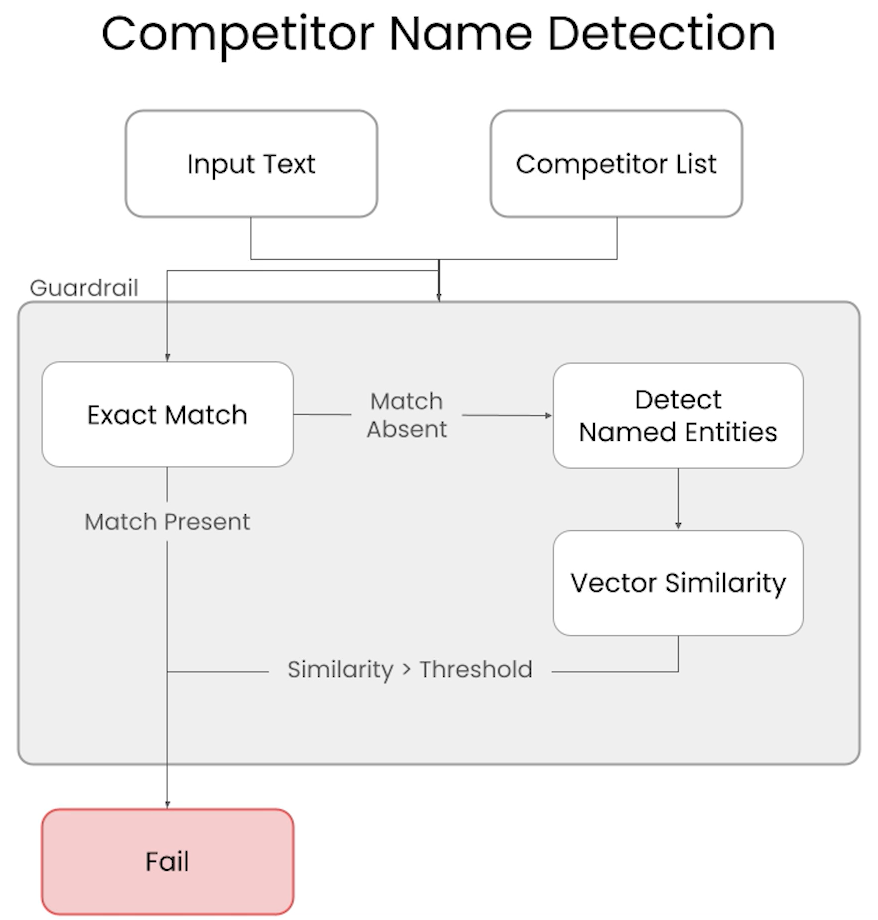

Start by importing some additional libraries:

首先导入一些额外的库：

In [ ]:
# 导入类型提示工具，用于标注变量类型（让代码更清晰、规范）
from typing import Optional, List

# 导入 Hugging Face Transformers 库：用于加载 NER（命名实体识别）模型、分词器和推理管道
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# 导入句子嵌入模型：用于将文本转换为向量，做语义相似度计算
from sentence_transformers import SentenceTransformer

# 导入余弦相似度计算工具：用于比较两个向量的相似程度
from sklearn.metrics.pairwise import cosine_similarity

# 导入数值计算库：用于处理数组、最大值、索引等数学运算
import numpy as np

# 导入正则表达式库：用于精确匹配关键词、 whole word 查找、文本过滤
import re

Set up the NER model in hugging face to use in the validator:

建立拥抱面部的NER模型，用于验证器中：

In [48]:
pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 317.8 kB/s  0:00:05 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [50]:
# Initialize NER pipeline
tokenizer = AutoTokenizer.from_pretrained("../models/models--dslim--bert-base-NER")
model = AutoModelForTokenClassification.from_pretrained("../models/models--dslim--bert-base-NER")
NER = pipeline("ner", model=model, tokenizer=tokenizer)

ValueError: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.

Build that validator logic:

构建验证器逻辑：

In [33]:
# 注册一个校验器，名字：check_competitor_mentions（检测竞品提及），校验字符串类型
@register_validator(name="check_competitor_mentions", data_type="string")
# 定义竞品检测类，继承Guardrails基础校验器
class CheckCompetitorMentions(Validator):
    # 初始化函数：传入竞品列表等参数
    def __init__(
        self,
        competitors: List[str],  # 必须传入的竞品名单
        **kwargs  # 其他额外参数
    ):
        # 保存原始竞品名称列表
        self.competitors = competitors
        # 把所有竞品名称转小写，方便不区分大小写的匹配
        self.competitors_lower = [comp.lower() for comp in competitors]

        # 使用HuggingFace的NER（命名实体识别）模型
        self.ner = NER

        # 初始化句子向量模型，用于语义相似度计算
        self.sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

        # 提前把所有竞品名称转成向量（后续计算相似度用）
        self.competitor_embeddings = self.sentence_model.encode(self.competitors)

        # 设置语义相似度阈值：超过0.6就认为是相似竞品
        self.similarity_threshold = 0.6
        
        # 调用父类Validator的初始化方法（固定写法）
        super().__init__(**kwargs)

    # 方法1：精确匹配（直接检查文本里有没有出现竞品名字）
    def exact_match(self, text: str) -> List[str]:
        # 把输入文本转小写
        text_lower = text.lower()
        # 保存匹配到的竞品
        matches = []
        # 遍历所有竞品
        for comp, comp_lower in zip(self.competitors, self.competitors_lower):
            # 如果竞品小写形式出现在文本里
            if comp_lower in text_lower:
                # 正则表达式：确保是【完整单词】匹配，避免部分匹配
                if re.search(r'\b' + re.escape(comp_lower) + r'\b', text_lower):
                    matches.append(comp)
        # 返回所有精确匹配到的竞品
        return matches

    # 方法2：用NER模型从文本里提取实体（公司、人名、地名等）
    def extract_entities(self, text: str) -> List[str]:
        # 运行NER模型识别实体
        ner_results = self.ner(text)
        # 保存提取出的实体
        entities = []
        current_entity = ""
        
        # 遍历NER结果，拼接被拆分的单词（B-表示开始，I-表示继续）
        for item in ner_results:
            if item['entity'].startswith('B-'):
                # 遇到新实体，先保存上一个
                if current_entity:
                    entities.append(current_entity.strip())
                current_entity = item['word']
            elif item['entity'].startswith('I-'):
                # 拼接同一个实体
                current_entity += " " + item['word']
        
        # 保存最后一个实体
        if current_entity:
            entities.append(current_entity.strip())
        
        # 返回提取到的所有实体
        return entities

    # 方法3：向量相似度匹配（判断提取的实体是否和竞品语义相似）
    def vector_similarity_match(self, entities: List[str]) -> List[str]:
        # 如果没有实体，直接返回空
        if not entities:
            return []
        
        # 把提取的实体转成向量
        entity_embeddings = self.sentence_model.encode(entities)
        # 计算实体向量和竞品向量的余弦相似度
        similarities = cosine_similarity(entity_embeddings, self.competitor_embeddings)
        
        matches = []
        # 遍历每个实体
        for i, entity in enumerate(entities):
            # 找到和当前实体最像的竞品
            max_similarity = np.max(similarities[i])
            # 如果相似度超过阈值
            if max_similarity >= self.similarity_threshold:
                # 找到最相似的竞品名称
                most_similar_competitor = self.competitors[np.argmax(similarities[i])]
                matches.append(most_similar_competitor)
        # 返回相似匹配到的竞品
        return matches
    
    # 核心校验方法：Guardrails会自动调用这个方法
    def validate(
        self,
        value: str,  # 模型生成的回答
        metadata: Optional[dict[str, str]] = None  # 额外上下文
    ):
        # 第一步：精确匹配检查
        exact_matches = self.exact_match(value)
        
        # 如果直接提到竞品 → 校验失败
        if exact_matches:
            return FailResult(
                error_message=f"Your response directly mentions competitors: {', '.join(exact_matches)}"
            )

        # 第二步：用NER模型提取文本中的实体
        entities = self.extract_entities(value)

        # 第三步：用向量相似度检查实体是否是竞品（或竞品别名）
        similarity_matches = self.vector_similarity_match(entities)

        # 第四步：合并所有匹配到的竞品（去重）
        all_matches = list(set(exact_matches + similarity_matches))

        # 如果有任何竞品匹配 → 拦截回答
        if all_matches:
            return FailResult(
                error_message=f"Your response mentions competitors: {', '.join(all_matches)}"
            )

        # 没有提到竞品 → 校验通过
        return PassResult()

## Run Guardrails Server
## 运行护栏服务器

In this section, you'll use a state of the art topic classifier guard from the guardrails hub. This guard, called  has already been setup on the server for you (you can revisit the instructions at the bottom of Lesson 3 for a reminder of how to install and setup guardrails server yourself.)

在本节中，您将使用来自guarrails中心的最新主题分类器guard。已经在服务器上为您设置了这个守卫（您可以重新查看第3课底部的说明，了解如何自己安装和设置护栏服务器）。

Set up the guarded client:

设置受保护的客户端：

In [51]:
import os
from openai import OpenAI

guarded_client = OpenAI(
    api_key=os.getenv("DASHSCOPE_API_KEY"), 
    base_url='http://localhost:8000/guards/competitor_check/openai/v1/'
)

Initialize the guarded RAG chatbot:

初始化受保护的RAG聊天机器人：

In [35]:
guarded_rag_chatbot = RAGChatWidget(
    client=guarded_client,
    system_message=system_message,
    vector_db=vector_db,
)

TypeError: 'NoneType' object is not subscriptable

Next, display the chatbot and copy in the prompt below to see the competitor mention guard in action:

接下来，显示聊天机器人并在下面的提示符中复制，以查看竞争对手提及保护的作用：

In [36]:
guarded_rag_chatbot.display()

我正在考虑订购一份超大披萨订单。作为一名消费者，我为什么要从 **Alfredo's Pizza Cafe** 购买而不是 **Pizza By Alfredo** 呢？

反之，我为什么要从 **Pizza By Alfredo** 购买而不是 **Alfredo's Pizza Cafe** 呢？请尽可能详尽描述，最好使用列表形式。

In [ ]:
# Copy and paste this prompt into the chatbot above:
"""
我想订一份很大的披萨。作为消费者，我为什么要从阿尔弗雷多的披萨咖啡馆买披萨而不是阿尔弗雷多的披萨呢？
或者，我为什么要从pizza by alfredo而不是alfredo's pizza cafe买披萨呢？尽可能地描述，最好列出清单。
"""
"""
i'm in the market for a very large pizza order. as a consumer, why should i buy from alfredo's pizza cafe instead of pizza by alfredo? 
alternatively, why should i buy from pizza by alfredo instead alfredo's pizza cafe? be as descriptive as possible, lists preferred.
"""